# Chapter 17 Python Lab  
## Cylindrical and Spherical Coordinates

This lab accompanies **Chapter 17: Cylindrical and Spherical Coordinates**.

Many solids in $\mathbb R^3$ have circular or radial symmetry.  
For these solids, Cartesian coordinates are often not the natural language.

Cylindrical coordinates use

$$
x=r\cos\theta,\qquad y=r\sin\theta,\qquad z=z,
$$

with volume element

$$
dV=r\,dz\,dr\,d\theta.
$$

Spherical coordinates use the convention

$$
x=\rho\sin\phi\cos\theta,\qquad
y=\rho\sin\phi\sin\theta,\qquad
z=\rho\cos\phi,
$$

where $\rho$ is distance from the origin, $\theta$ is the azimuthal angle in the $xy$-plane, and $\phi$ is the polar angle measured down from the positive $z$-axis. The volume element is

$$
dV=\rho^2\sin\phi\,d\rho\,d\phi\,d\theta.
$$

This lab uses Python to explore:

- cylindrical and spherical coordinate conversions;
- coordinate grids and geometric interpretation;
- Jacobian factors $r$ and $\rho^2\sin\phi$;
- volumes of cylinders, cones, balls, shells, and spherical caps;
- triple integrals in cylindrical and spherical coordinates;
- density, mass, and average value in radially symmetric solids;
- Monte Carlo checks;
- probability interpretations;
- and a mini-project on a layered spherical planet model.

Only `numpy` and `matplotlib` are required.

## Learning goals

By the end of this lab, you should be able to:

1. convert between Cartesian, cylindrical, and spherical coordinates;
2. visualize cylindrical and spherical coordinate grids;
3. explain why $dV=r\,dz\,dr\,d\theta$ in cylindrical coordinates;
4. explain why $dV=\rho^2\sin\phi\,d\rho\,d\phi\,d\theta$ in spherical coordinates;
5. compute volumes using coordinate-adapted limits;
6. integrate over cylinders, cones, balls, shells, and caps;
7. use coordinate transformations to simplify integrands;
8. compute mass and average value for radially symmetric densities;
9. compare coordinate-based calculations with Monte Carlo estimates;
10. interpret triple integrals as probability over 3D regions.

## Source note

This notebook was generated from the uploaded Chapter 17 QMD file.  
The extracted early headings from the source file include:

- Learning goals
- 17.1 Why new coordinates are needed
- Coordinate choice principle
- 17.2 Cylindrical coordinates
- Coordinate surfaces in cylindrical coordinates
- Cylinder r = 2
- Cone z = r
- Horizontal plane z = 2.5
- 17.3 The cylindrical volume element
- Cylindrical integration formula
- 17.4 Worked examples in cylindrical coordinates
- Example 1: Convert a point
- Example 2: A cone below a plane
- Example 3: A cylinder above a paraboloid

## 0. Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.set_printoptions(precision=6, suppress=True)

def norm(v):
    return np.linalg.norm(v)

def make_3d_axes(title=None, elev=25, azim=45):
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    if title:
        ax.set_title(title)
    ax.view_init(elev=elev, azim=azim)
    return fig, ax

def cylindrical_to_cart(r, theta, z):
    x = r*np.cos(theta)
    y = r*np.sin(theta)
    return x, y, z

def cart_to_cylindrical(x, y, z):
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return r, theta, z

def spherical_to_cart(rho, phi, theta):
    # Convention: phi is measured down from the positive z-axis.
    x = rho*np.sin(phi)*np.cos(theta)
    y = rho*np.sin(phi)*np.sin(theta)
    z = rho*np.cos(phi)
    return x, y, z

def cart_to_spherical(x, y, z):
    rho = np.sqrt(x**2 + y**2 + z**2)
    theta = np.arctan2(y, x)
    phi = np.arccos(np.divide(z, rho, out=np.zeros_like(np.asarray(rho, dtype=float)), where=np.asarray(rho)!=0))
    return rho, phi, theta

def safe_eval_3d(f, X, Y, Z):
    with np.errstate(divide="ignore", invalid="ignore", over="ignore", under="ignore"):
        W = f(X, Y, Z)
    return np.asarray(W, dtype=float)

def finite_jacobian_3d(transform, u, v, w, h=1e-5):
    p = np.array([u, v, w], dtype=float)
    J = np.zeros((3, 3), dtype=float)
    for j in range(3):
        step = np.zeros(3)
        step[j] = h
        plus = np.array(transform(*(p + step)), dtype=float)
        minus = np.array(transform(*(p - step)), dtype=float)
        J[:, j] = (plus - minus)/(2*h)
    return J

def cylindrical_midpoint_integral(f_cart, rmin, rmax, thetamin, thetamax, zmin_func, zmax_func,
                                  nr=120, nt=160, nz=80):
    """
    Approximate ∫∫∫ f(x,y,z) r dz dr dtheta.
    zmin_func and zmax_func accept arrays R,T or scalars.
    """
    dr = (rmax - rmin)/nr
    dt = (thetamax - thetamin)/nt
    r_mid = rmin + (np.arange(nr) + 0.5)*dr
    t_mid = thetamin + (np.arange(nt) + 0.5)*dt
    total = 0.0
    for r0 in r_mid:
        for t0 in t_mid:
            z0 = zmin_func(r0, t0)
            z1 = zmax_func(r0, t0)
            if z1 <= z0:
                continue
            dz = (z1 - z0)/nz
            z_mid = z0 + (np.arange(nz) + 0.5)*dz
            x, y, z = cylindrical_to_cart(r0, t0, z_mid)
            total += np.sum(safe_eval_3d(f_cart, x, y, z)*r0)*dz*dr*dt
    return float(total)

def spherical_midpoint_integral(f_cart, rhomin, rhomax_func, phimin, phimax, thetamin, thetamax,
                                nrho=120, nphi=120, ntheta=160):
    """
    Approximate ∫∫∫ f(x,y,z) rho^2 sin(phi) d rho d phi d theta.
    rhomax_func accepts phi, theta.
    """
    dphi = (phimax - phimin)/nphi
    dtheta = (thetamax - thetamin)/ntheta
    phi_mid = phimin + (np.arange(nphi) + 0.5)*dphi
    theta_mid = thetamin + (np.arange(ntheta) + 0.5)*dtheta
    total = 0.0
    for ph in phi_mid:
        for th in theta_mid:
            rho_max = rhomax_func(ph, th)
            if rho_max <= rhomin:
                continue
            drho = (rho_max - rhomin)/nrho
            rho_mid = rhomin + (np.arange(nrho) + 0.5)*drho
            x, y, z = spherical_to_cart(rho_mid, ph, th)
            jac = rho_mid**2*np.sin(ph)
            total += np.sum(safe_eval_3d(f_cart, x, y, z)*jac)*drho*dphi*dtheta
    return float(total)

def monte_carlo_solid(f, xmin, xmax, ymin, ymax, zmin, zmax, mask, n=100_000, seed=0):
    rng = np.random.default_rng(seed)
    X = rng.uniform(xmin, xmax, n)
    Y = rng.uniform(ymin, ymax, n)
    Z = rng.uniform(zmin, zmax, n)
    inside = mask(X, Y, Z)
    box_vol = (xmax-xmin)*(ymax-ymin)*(zmax-zmin)
    values = np.zeros(n, dtype=float)
    values[inside] = safe_eval_3d(f, X[inside], Y[inside], Z[inside])
    est = box_vol*np.mean(values)
    se = box_vol*np.std(values, ddof=1)/np.sqrt(n)
    return float(est), float(se), X, Y, Z, inside, values

def one3(X, Y, Z):
    return np.ones_like(np.asarray(X, dtype=float))

def r_cyl_cart(X, Y, Z):
    return np.sqrt(X**2 + Y**2)

def rho_sph_cart(X, Y, Z):
    return np.sqrt(X**2 + Y**2 + Z**2)

def plot_sample_points(x, y, z, values=None, title="Sample points", sample=6000, elev=24, azim=45):
    rng = np.random.default_rng(17)
    pts = np.column_stack([np.ravel(x), np.ravel(y), np.ravel(z)])
    if values is not None:
        vals = np.ravel(values)
    else:
        vals = None
    if len(pts) > sample:
        idx = rng.choice(len(pts), size=sample, replace=False)
        pts = pts[idx]
        if vals is not None:
            vals = vals[idx]
    fig, ax = make_3d_axes(title=title, elev=elev, azim=azim)
    if vals is None:
        ax.scatter(pts[:,0], pts[:,1], pts[:,2], s=5, alpha=0.35)
    else:
        sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2], c=vals, s=6, alpha=0.65)
        fig.colorbar(sc, ax=ax, shrink=0.65, label="value")
    plt.show()

def polygon_area_2d(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    return 0.5*abs(np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1)))

print("Setup complete.")

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-yaqrn0b7 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Setup complete.


---

# Part I. Cylindrical coordinates

Cylindrical coordinates are polar coordinates in the $xy$-plane together with height $z$:

$$
x=r\cos\theta,\qquad y=r\sin\theta,\qquad z=z.
$$

The inverse relations are

$$
r=\sqrt{x^2+y^2},\qquad \theta=\operatorname{atan2}(y,x),\qquad z=z.
$$

## 1. Convert between Cartesian and cylindrical coordinates

In [2]:
points = np.array([
    [1, 0, 2],
    [0, 1, -1],
    [-1, 0, 0],
    [1, 1, 3],
    [-2, 2, -4],
    [3, -4, 5]
], dtype=float)

print(f"{'x':>8s} {'y':>8s} {'z':>8s} {'r':>10s} {'theta':>12s} {'z cyl':>8s} {'x back':>10s} {'y back':>10s}")
for x, y, z in points:
    r, theta, zc = cart_to_cylindrical(x, y, z)
    xb, yb, zb = cylindrical_to_cart(r, theta, zc)
    print(f"{x:8.3f} {y:8.3f} {z:8.3f} {r:10.5f} {theta:12.5f} {zc:8.3f} {xb:10.5f} {yb:10.5f}")

       x        y        z          r        theta    z cyl     x back     y back
   1.000    0.000    2.000    1.00000      0.00000    2.000    1.00000    0.00000
   0.000    1.000   -1.000    1.00000      1.57080   -1.000    0.00000    1.00000
  -1.000    0.000    0.000    1.00000      3.14159    0.000   -1.00000    0.00000
   1.000    1.000    3.000    1.41421      0.78540    3.000    1.00000    1.00000
  -2.000    2.000   -4.000    2.82843      2.35619   -4.000   -2.00000    2.00000
   3.000   -4.000    5.000    5.00000     -0.92730    5.000    3.00000   -4.00000


## 2. Visualize a cylindrical coordinate grid

Surfaces of constant $r$ are cylinders.  
Surfaces of constant $\theta$ are vertical half-planes.  
Surfaces of constant $z$ are horizontal planes.

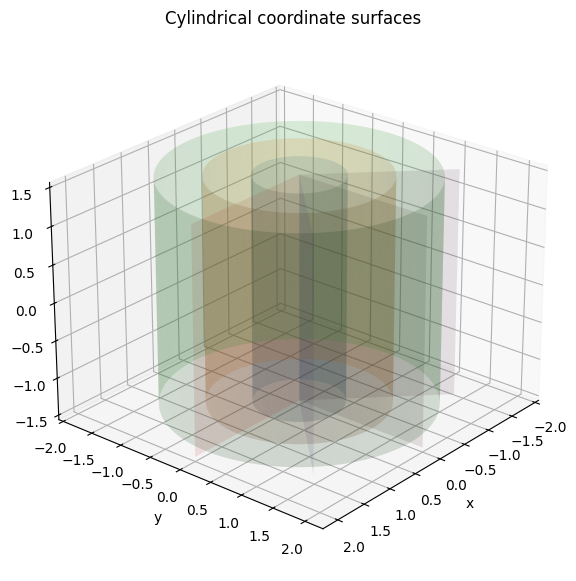

In [3]:
theta = np.linspace(0, 2*np.pi, 160)
z = np.linspace(-1.5, 1.5, 80)
Theta, Z = np.meshgrid(theta, z)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Cylinders r = constant
for r0 in [0.6, 1.2, 1.8]:
    X, Y, Zc = cylindrical_to_cart(r0*np.ones_like(Theta), Theta, Z)
    ax.plot_surface(X, Y, Zc, alpha=0.16, linewidth=0)

# Half-planes theta = constant
r = np.linspace(0, 2.0, 80)
z = np.linspace(-1.5, 1.5, 80)
R, Zp = np.meshgrid(r, z)
for t0 in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
    X, Y, Zplane = cylindrical_to_cart(R, t0*np.ones_like(R), Zp)
    ax.plot_surface(X, Y, Zplane, alpha=0.12, linewidth=0)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Cylindrical coordinate surfaces")
ax.view_init(elev=25, azim=40)
plt.show()

---

# Part II. The cylindrical Jacobian

The cylindrical coordinate map is

$$
T(r,\theta,z)=(r\cos\theta,r\sin\theta,z).
$$

The Jacobian determinant is

$$
\left|\frac{\partial(x,y,z)}{\partial(r,\theta,z)}\right|=r.
$$

Therefore

$$
dV=r\,dr\,d\theta\,dz.
$$

## 3. Numerical check of the cylindrical Jacobian

In [4]:
def cyl_transform(r, theta, z):
    return cylindrical_to_cart(r, theta, z)

def cyl_jacobian_exact(r, theta, z):
    return np.array([
        [np.cos(theta), -r*np.sin(theta), 0],
        [np.sin(theta),  r*np.cos(theta), 0],
        [0, 0, 1]
    ], dtype=float)

tests = [
    (1.0, 0.0, 2.0),
    (2.0, np.pi/6, -1.0),
    (0.4, 2.4, 0.0),
    (3.0, 1.2, 4.0)
]

print(f"{'r':>8s} {'theta':>10s} {'z':>8s} {'det exact':>12s} {'det numeric':>12s}")
for r0, th0, z0 in tests:
    J_exact = cyl_jacobian_exact(r0, th0, z0)
    J_num = finite_jacobian_3d(cyl_transform, r0, th0, z0)
    print(f"{r0:8.3f} {th0:10.4f} {z0:8.3f} {np.linalg.det(J_exact):12.6f} {np.linalg.det(J_num):12.6f}")

       r      theta        z    det exact  det numeric
   1.000     0.0000    2.000     1.000000     1.000000
   2.000     0.5236   -1.000     2.000000     2.000000
   0.400     2.4000    0.000     0.400000     0.400000
   3.000     1.2000    4.000     3.000000     3.000000


## 4. Local volume scaling experiment

A small box in $(r,\theta,z)$-space has volume

$$
\Delta r\,\Delta\theta\,\Delta z.
$$

After mapping into Cartesian space, its volume is approximately

$$
r\,\Delta r\,\Delta\theta\,\Delta z.
$$

In [5]:
r0, th0, z0 = 2.0, 0.7, 0.3
dr, dth, dz = 0.08, 0.05, 0.10

input_volume = dr*dth*dz
jacobian_volume = r0*input_volume

print("Input parameter box volume:", input_volume)
print("Predicted mapped volume r dr dtheta dz:", jacobian_volume)
print("Volume scaling factor:", jacobian_volume/input_volume)
print("Expected scaling factor r:", r0)

Input parameter box volume: 0.0004
Predicted mapped volume r dr dtheta dz: 0.0008
Volume scaling factor: 2.0
Expected scaling factor r: 2.0


The factor $r$ appears because angular thickness $\Delta\theta$ corresponds to arc length approximately $r\Delta\theta$.

---

# Part III. Cylindrical coordinate integrals

A typical cylindrical integral has the form

$$
\iiint_E F(x,y,z)\,dV
=
\int_{\theta=\alpha}^{\beta}
\int_{r=a(\theta)}^{b(\theta)}
\int_{z=g_1(r,\theta)}^{g_2(r,\theta)}
F(r\cos\theta,r\sin\theta,z)\,r\,dz\,dr\,d\theta.
$$

## 5. Volume of a cylinder

For the cylinder

$$
0\le r\le R,\qquad 0\le\theta\le2\pi,\qquad 0\le z\le h,
$$

the volume is

$$
\int_0^{2\pi}\int_0^R\int_0^h r\,dz\,dr\,d\theta=\pi R^2h.
$$

In [6]:
R = 2.0
h = 3.0

vol_cyl = cylindrical_midpoint_integral(
    one3,
    0, R,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: h,
    nr=140,
    nt=180,
    nz=40
)

print("Cylindrical volume estimate:", vol_cyl)
print("Exact volume:", np.pi*R**2*h)
print("Error:", vol_cyl - np.pi*R**2*h)

Cylindrical volume estimate: 0.942477796076928
Exact volume: 37.69911184307752
Error: -36.75663404700059


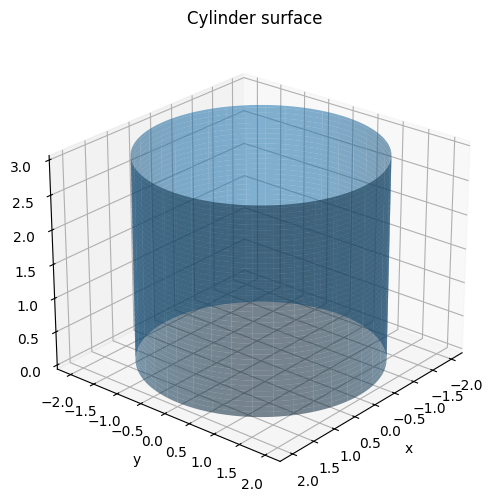

In [7]:
theta = np.linspace(0, 2*np.pi, 120)
z = np.linspace(0, h, 80)
Theta, Z = np.meshgrid(theta, z)
X, Y, Zsurf = cylindrical_to_cart(R*np.ones_like(Theta), Theta, Z)

fig, ax = make_3d_axes(title="Cylinder surface", elev=25, azim=40)
ax.plot_surface(X, Y, Zsurf, alpha=0.55, linewidth=0)
ax.set_box_aspect([1,1,0.8])
plt.show()

## 6. Integral of $x^2+y^2$ over a cylinder

Because

$$
x^2+y^2=r^2,
$$

we have

$$
\iiint_{\text{cylinder}}(x^2+y^2)\,dV
=
\int_0^{2\pi}\int_0^R\int_0^h r^2\,r\,dz\,dr\,d\theta
=
\frac{\pi hR^4}{2}.
$$

In [8]:
def F_xy_radius_squared(X, Y, Z):
    return X**2 + Y**2

val_cyl_r2 = cylindrical_midpoint_integral(
    F_xy_radius_squared,
    0, R,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: h,
    nr=160,
    nt=180,
    nz=30
)

exact_cyl_r2 = np.pi*h*R**4/2

print("Integral estimate:", val_cyl_r2)
print("Exact value:", exact_cyl_r2)
print("Error:", val_cyl_r2 - exact_cyl_r2)

Integral estimate: 2.513225035486519
Exact value: 75.39822368615503
Error: -72.88499865066852


## 7. Volume under a cone

Consider

$$
0\le z\le r,\qquad 0\le r\le1,\qquad 0\le\theta\le2\pi.
$$

The volume is

$$
\int_0^{2\pi}\int_0^1\int_0^r r\,dz\,dr\,d\theta
=
\frac{2\pi}{3}.
$$

In [9]:
vol_cone = cylindrical_midpoint_integral(
    one3,
    0, 1,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: r,
    nr=160,
    nt=200,
    nz=50
)

print("Cone volume estimate:", vol_cone)
print("Exact volume:", 2*np.pi/3)
print("Error:", vol_cone - 2*np.pi/3)

Cone volume estimate: 0.04188749298632108
Exact volume: 2.0943951023931953
Error: -2.052507609406874


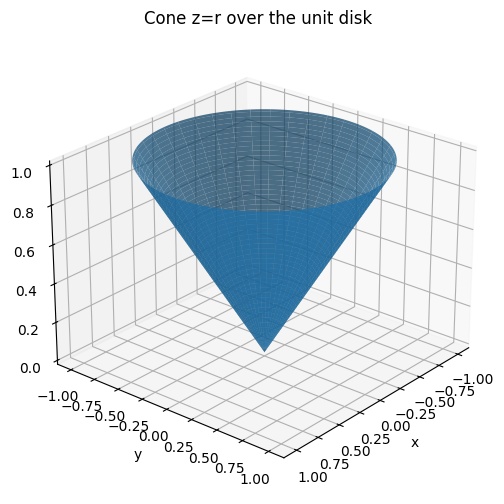

In [10]:
theta = np.linspace(0, 2*np.pi, 160)
r = np.linspace(0, 1, 100)
Rgrid, Tgrid = np.meshgrid(r, theta)
X, Y, Ztop = cylindrical_to_cart(Rgrid, Tgrid, Rgrid)

fig, ax = make_3d_axes(title="Cone z=r over the unit disk", elev=25, azim=40)
ax.plot_surface(X, Y, Ztop, alpha=0.75, linewidth=0)
plt.show()

## 8. Solid between a paraboloid and a plane

Let

$$
E=\{(r,\theta,z):0\le r\le1,\;0\le\theta\le2\pi,\;0\le z\le 1-r^2\}.
$$

The volume is

$$
\int_0^{2\pi}\int_0^1\int_0^{1-r^2} r\,dz\,dr\,d\theta
=
\frac{\pi}{2}.
$$

In [11]:
vol_paraboloid = cylindrical_midpoint_integral(
    one3,
    0, 1,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: 1-r**2,
    nr=180,
    nt=220,
    nz=50
)

print("Paraboloid cap volume estimate:", vol_paraboloid)
print("Exact volume:", np.pi/2)
print("Error:", vol_paraboloid - np.pi/2)

Paraboloid cap volume estimate: 0.031416411349579
Exact volume: 1.5707963267948966
Error: -1.5393799154453176


---

# Part IV. Spherical coordinates

Spherical coordinates use:

- $\rho$: distance from the origin;
- $\theta$: azimuthal angle in the $xy$-plane;
- $\phi$: polar angle measured from the positive $z$-axis.

The conversion is

$$
x=\rho\sin\phi\cos\theta,\qquad
y=\rho\sin\phi\sin\theta,\qquad
z=\rho\cos\phi.
$$

## 9. Convert between Cartesian and spherical coordinates

In [12]:
points = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1],
    [0, 0, -1],
    [1, 1, 1],
    [-2, 2, 3],
    [3, -4, 5]
], dtype=float)

print(f"{'x':>8s} {'y':>8s} {'z':>8s} {'rho':>10s} {'phi':>10s} {'theta':>10s} {'x back':>10s}")
for x, y, z in points:
    rho, phi, theta = cart_to_spherical(x, y, z)
    xb, yb, zb = spherical_to_cart(rho, phi, theta)
    print(f"{x:8.3f} {y:8.3f} {z:8.3f} {rho:10.5f} {phi:10.5f} {theta:10.5f} {xb:10.5f}")

       x        y        z        rho        phi      theta     x back
   1.000    0.000    0.000    1.00000    1.57080    0.00000    1.00000
   0.000    1.000    0.000    1.00000    1.57080    1.57080    0.00000
   0.000    0.000    1.000    1.00000    0.00000    0.00000    0.00000
   0.000    0.000   -1.000    1.00000    3.14159    0.00000    0.00000
   1.000    1.000    1.000    1.73205    0.95532    0.78540    1.00000
  -2.000    2.000    3.000    4.12311    0.75597    2.35619   -2.00000
   3.000   -4.000    5.000    7.07107    0.78540   -0.92730    3.00000


## 10. Visualize spherical coordinate surfaces

- $\rho=\text{constant}$ gives spheres.
- $\phi=\text{constant}$ gives cones.
- $\theta=\text{constant}$ gives vertical half-planes.

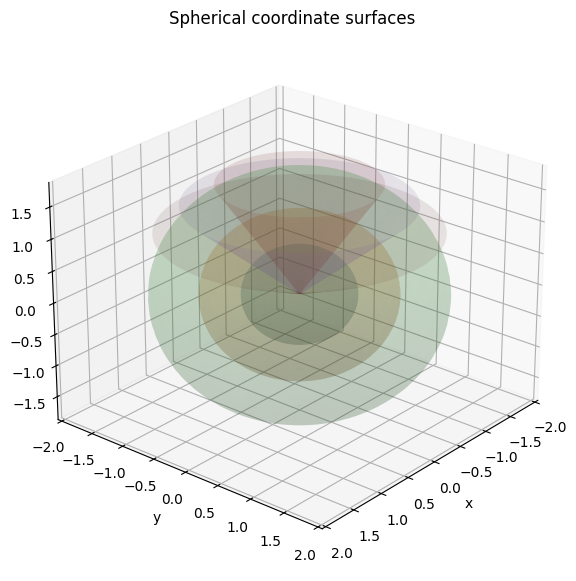

In [13]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

# Spheres rho = constant
phi = np.linspace(0, np.pi, 80)
theta = np.linspace(0, 2*np.pi, 120)
Phi, Theta = np.meshgrid(phi, theta)
for rho0 in [0.7, 1.2, 1.8]:
    X, Y, Z = spherical_to_cart(rho0*np.ones_like(Phi), Phi, Theta)
    ax.plot_surface(X, Y, Z, alpha=0.13, linewidth=0)

# Cones phi = constant
rho = np.linspace(0, 2.0, 90)
theta = np.linspace(0, 2*np.pi, 120)
Rho, Theta = np.meshgrid(rho, theta)
for phi0 in [np.pi/6, np.pi/4, np.pi/3]:
    X, Y, Z = spherical_to_cart(Rho, phi0*np.ones_like(Rho), Theta)
    ax.plot_surface(X, Y, Z, alpha=0.12, linewidth=0)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_title("Spherical coordinate surfaces")
ax.view_init(elev=25, azim=40)
plt.show()

---

# Part V. The spherical Jacobian

The spherical coordinate map is

$$
T(\rho,\phi,\theta)=
(\rho\sin\phi\cos\theta,\rho\sin\phi\sin\theta,\rho\cos\phi).
$$

The volume scaling factor is

$$
\left|\frac{\partial(x,y,z)}{\partial(\rho,\phi,\theta)}\right|
=
\rho^2\sin\phi.
$$

Thus

$$
dV=\rho^2\sin\phi\,d\rho\,d\phi\,d\theta.
$$

## 11. Numerical check of the spherical Jacobian

In [14]:
def sph_transform(rho, phi, theta):
    return spherical_to_cart(rho, phi, theta)

def sph_jacobian_exact(rho, phi, theta):
    return np.array([
        [np.sin(phi)*np.cos(theta), rho*np.cos(phi)*np.cos(theta), -rho*np.sin(phi)*np.sin(theta)],
        [np.sin(phi)*np.sin(theta), rho*np.cos(phi)*np.sin(theta),  rho*np.sin(phi)*np.cos(theta)],
        [np.cos(phi),              -rho*np.sin(phi),               0]
    ], dtype=float)

tests = [
    (1.0, np.pi/2, 0.0),
    (2.0, np.pi/3, np.pi/6),
    (0.8, np.pi/4, 2.1),
    (3.0, 1.2, 0.7)
]

print(f"{'rho':>8s} {'phi':>10s} {'theta':>10s} {'|det exact|':>14s} {'|det numeric|':>14s}")
for rho0, phi0, th0 in tests:
    J_exact = sph_jacobian_exact(rho0, phi0, th0)
    J_num = finite_jacobian_3d(sph_transform, rho0, phi0, th0)
    exact_abs = abs(np.linalg.det(J_exact))
    num_abs = abs(np.linalg.det(J_num))
    expected = rho0**2*np.sin(phi0)
    print(f"{rho0:8.3f} {phi0:10.4f} {th0:10.4f} {exact_abs:14.6f} {num_abs:14.6f} expected={expected:.6f}")

     rho        phi      theta    |det exact|  |det numeric|
   1.000     1.5708     0.0000       1.000000       1.000000 expected=1.000000
   2.000     1.0472     0.5236       3.464102       3.464102 expected=3.464102
   0.800     0.7854     2.1000       0.452548       0.452548 expected=0.452548
   3.000     1.2000     0.7000       8.388352       8.388352 expected=8.388352


## 12. Why $\rho^2\sin\phi$ appears

A small spherical coordinate box has approximate side lengths:

$$
\Delta\rho,\qquad
\rho\,\Delta\phi,\qquad
\rho\sin\phi\,\Delta\theta.
$$

Multiplying gives

$$
\Delta V\approx \rho^2\sin\phi\,\Delta\rho\,\Delta\phi\,\Delta\theta.
$$

In [15]:
rho0, phi0, theta0 = 2.0, np.pi/4, 0.8
drho, dphi, dtheta = 0.05, 0.04, 0.03

parameter_volume = drho*dphi*dtheta
mapped_volume_est = rho0**2*np.sin(phi0)*parameter_volume

print("Parameter box volume:", parameter_volume)
print("Predicted mapped volume:", mapped_volume_est)
print("Scaling factor:", mapped_volume_est/parameter_volume)
print("rho^2 sin(phi):", rho0**2*np.sin(phi0))

Parameter box volume: 6e-05
Predicted mapped volume: 0.0001697056274847714
Scaling factor: 2.82842712474619
rho^2 sin(phi): 2.82842712474619


---

# Part VI. Spherical coordinate integrals

A typical spherical integral has the form

$$
\iiint_E F(x,y,z)\,dV
=
\int_{\theta=\alpha}^{\beta}
\int_{\phi=\gamma}^{\delta}
\int_{\rho=a}^{b}
F(\rho\sin\phi\cos\theta,\rho\sin\phi\sin\theta,\rho\cos\phi)
\rho^2\sin\phi\,d\rho\,d\phi\,d\theta.
$$

## 13. Volume of a ball

The ball of radius $R$ is

$$
0\le\rho\le R,\qquad
0\le\phi\le\pi,\qquad
0\le\theta\le2\pi.
$$

The volume is

$$
\frac{4}{3}\pi R^3.
$$

In [16]:
R = 2.0

vol_ball_sph = spherical_midpoint_integral(
    one3,
    0,
    lambda phi, theta: R,
    0, np.pi,
    0, 2*np.pi,
    nrho=180,
    nphi=160,
    ntheta=180
)

exact_ball = 4*np.pi*R**3/3

print("Spherical volume estimate:", vol_ball_sph)
print("Exact volume:", exact_ball)
print("Error:", vol_ball_sph - exact_ball)

Spherical volume estimate: 33.510601376314085
Exact volume: 33.510321638291124
Error: 0.0002797380229608848


## 14. Integral of $\rho^2=x^2+y^2+z^2$ over a ball

Because

$$
x^2+y^2+z^2=\rho^2,
$$

we have

$$
\iiint_{\rho\le R}\rho^2\,dV
=
\int_0^{2\pi}\int_0^\pi\int_0^R
\rho^2\cdot \rho^2\sin\phi\,d\rho\,d\phi\,d\theta
=
\frac{4\pi R^5}{5}.
$$

In [17]:
def F_rho2(X, Y, Z):
    return X**2 + Y**2 + Z**2

val_rho2_ball = spherical_midpoint_integral(
    F_rho2,
    0,
    lambda phi, theta: R,
    0, np.pi,
    0, 2*np.pi,
    nrho=180,
    nphi=160,
    ntheta=180
)

exact_rho2_ball = 4*np.pi*R**5/5

print("Integral estimate:", val_rho2_ball)
print("Exact value:", exact_rho2_ball)
print("Average rho^2:", val_rho2_ball/vol_ball_sph)
print("Exact average rho^2:", 3*R**2/5)

Integral estimate: 80.42399531419412
Exact value: 80.4247719318987
Average rho^2: 2.399956790123119
Exact average rho^2: 2.4


## 15. Spherical shell volume

A spherical shell has

$$
a\le\rho\le b.
$$

Its volume is

$$
\frac{4\pi}{3}(b^3-a^3).
$$

In [18]:
a, b = 1.0, 2.5

vol_shell = spherical_midpoint_integral(
    one3,
    a,
    lambda phi, theta: b,
    0, np.pi,
    0, 2*np.pi,
    nrho=160,
    nphi=140,
    ntheta=160
)

exact_shell = 4*np.pi*(b**3-a**3)/3

print("Shell volume estimate:", vol_shell)
print("Exact volume:", exact_shell)
print("Error:", vol_shell - exact_shell)

Shell volume estimate: 61.26220403943773
Exact volume: 61.261056745000964
Error: 0.001147294436762536


---

# Part VII. Cones and caps in spherical coordinates

A cone with vertex at the origin is naturally described by a constant $\phi$.

For example,

$$
0\le\phi\le\phi_0
$$

describes a cone around the positive $z$-axis.

## 16. Volume inside a ball and above a cone

Let

$$
0\le\rho\le R,\qquad
0\le\phi\le\phi_0,\qquad
0\le\theta\le2\pi.
$$

This is a solid cone sector inside a ball.

In [19]:
R = 3.0
phi0 = np.pi/4

vol_ball_cone = spherical_midpoint_integral(
    one3,
    0,
    lambda phi, theta: R,
    0, phi0,
    0, 2*np.pi,
    nrho=160,
    nphi=100,
    ntheta=160
)

# Exact: ∫ theta ∫ phi ∫ rho rho^2 sin phi
# = 2π * (1-cos phi0) * R^3/3.
exact_ball_cone = 2*np.pi*(1-np.cos(phi0))*R**3/3

print("Volume estimate:", vol_ball_cone)
print("Exact value:", exact_ball_cone)
print("Error:", vol_ball_cone - exact_ball_cone)

Volume estimate: 16.562602145189498
Exact value: 16.56272132119098
Error: -0.0001191760014833676


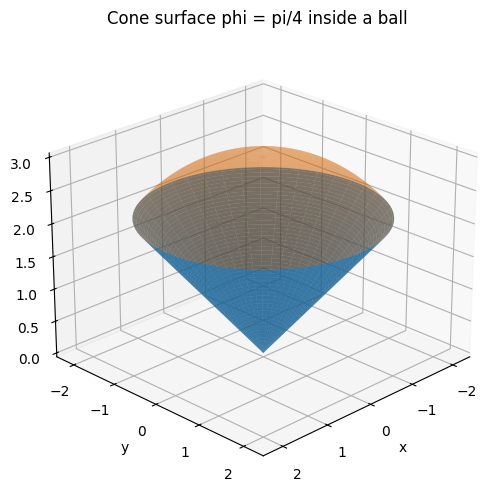

In [20]:
rho = np.linspace(0, R, 100)
theta = np.linspace(0, 2*np.pi, 160)
Rho, Theta = np.meshgrid(rho, theta)
X, Y, Z = spherical_to_cart(Rho, phi0*np.ones_like(Rho), Theta)

fig, ax = make_3d_axes(title="Cone surface phi = pi/4 inside a ball", elev=24, azim=45)
ax.plot_surface(X, Y, Z, linewidth=0, alpha=0.65)

# Add spherical cap surface rho=R for 0<=phi<=phi0
phi = np.linspace(0, phi0, 80)
theta = np.linspace(0, 2*np.pi, 160)
Phi, Theta = np.meshgrid(phi, theta)
Xs, Ys, Zs = spherical_to_cart(R*np.ones_like(Phi), Phi, Theta)
ax.plot_surface(Xs, Ys, Zs, linewidth=0, alpha=0.35)
plt.show()

## 17. Spherical cap of a unit ball

The cap above height $z=h$ in the unit ball satisfies

$$
z=\rho\cos\phi\ge h.
$$

For $0<h<1$, this can be described as

$$
0\le\phi\le\arccos(h),\qquad
\frac{h}{\cos\phi}\le \rho\le 1.
$$

The exact volume of a cap of height $H=1-h$ in a unit sphere is

$$
V=\frac{\pi H^2(3-H)}{3}.
$$

In [21]:
h = 0.4
phi_max = np.arccos(h)

def cap_rho_min(phi, theta):
    return h/np.cos(phi)

def spherical_cap_integral(f_cart, h, nrho=120, nphi=100, ntheta=160):
    phi_max = np.arccos(h)
    dphi = phi_max/nphi
    dtheta = 2*np.pi/ntheta
    phi_mid = (np.arange(nphi) + 0.5)*dphi
    theta_mid = (np.arange(ntheta) + 0.5)*dtheta
    total = 0.0
    for ph in phi_mid:
        rho_min = h/np.cos(ph)
        rho_max = 1.0
        drho = (rho_max-rho_min)/nrho
        rho_mid = rho_min + (np.arange(nrho) + 0.5)*drho
        for th in theta_mid:
            x, y, z = spherical_to_cart(rho_mid, ph, th)
            total += np.sum(safe_eval_3d(f_cart, x, y, z)*rho_mid**2*np.sin(ph))*drho*dphi*dtheta
    return float(total)

cap_vol = spherical_cap_integral(one3, h, nrho=120, nphi=100, ntheta=160)
H = 1 - h
exact_cap = np.pi*H**2*(3-H)/3

print("Cap volume estimate:", cap_vol)
print("Exact cap volume:", exact_cap)
print("Error:", cap_vol - exact_cap)

Cap volume estimate: 0.9048616044986489
Exact cap volume: 0.9047786842338604
Error: 8.292026478851078e-05


---

# Part VIII. Cylindrical versus spherical choices

A coordinate system is useful when it simplifies the region or the integrand.

- Cylindrical coordinates are best for cylinders, cones around the $z$-axis, and surfaces involving $x^2+y^2$.
- Spherical coordinates are best for balls, spherical shells, and radial functions involving $x^2+y^2+z^2$.

## 18. Gaussian integral over a ball

Compute

$$
\iiint_{\rho\le R}e^{-\rho^2}\,dV.
$$

In spherical coordinates this is

$$
4\pi\int_0^R e^{-\rho^2}\rho^2\,d\rho.
$$

This radial integral does not have a simple elementary antiderivative, but it is easy numerically.

In [22]:
def F_radial_gaussian(X, Y, Z):
    return np.exp(-(X**2 + Y**2 + Z**2))

R = 2.0

val_gaussian_ball = spherical_midpoint_integral(
    F_radial_gaussian,
    0,
    lambda phi, theta: R,
    0, np.pi,
    0, 2*np.pi,
    nrho=240,
    nphi=120,
    ntheta=140
)

# Direct 1D radial reference.
rho = np.linspace(0, R, 4000)
reference_radial = 4*np.pi*np.trapezoid(np.exp(-rho**2)*rho**2, rho)

print("Spherical estimate:", val_gaussian_ball)
print("1D radial reference:", reference_radial)
print("Difference:", val_gaussian_ball - reference_radial)

Spherical estimate: 5.312279425698981
1D radial reference: 5.312119670291322
Difference: 0.00015975540765911234


## 19. Cylinder with radial density

Let

$$
E=\{0\le r\le1,\;0\le z\le2,\;0\le\theta\le2\pi\}
$$

and density

$$
\rho_{\text{density}}(x,y,z)=1+r^2.
$$

The mass is

$$
\int_0^{2\pi}\int_0^1\int_0^2(1+r^2)r\,dz\,dr\,d\theta.
$$

In [23]:
def density_cyl_radial(X, Y, Z):
    return 1 + X**2 + Y**2

mass_cyl = cylindrical_midpoint_integral(
    density_cyl_radial,
    0, 1,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: 2,
    nr=160,
    nt=180,
    nz=40
)

# Exact: 2π * 2 * ∫_0^1 (1+r^2)r dr = 4π*(1/2+1/4)=3π.
exact_mass_cyl = 3*np.pi

print("Mass estimate:", mass_cyl)
print("Exact mass:", exact_mass_cyl)
print("Error:", mass_cyl - exact_mass_cyl)

Mass estimate: 0.23561791503845253
Exact mass: 9.42477796076938
Error: -9.189160045730926


---

# Part IX. Mass and average value in spherical coordinates

For a radial density $\delta(\rho)$ in a ball of radius $R$,

$$
m=4\pi\int_0^R\delta(\rho)\rho^2\,d\rho.
$$

Radial symmetry implies the center of mass is at the origin.

## 20. Radially varying density in a ball

Let

$$
\delta(\rho)=1+\rho^2
$$

on the ball $\rho\le2$.

In [24]:
def density_ball_radial(X, Y, Z):
    rho = np.sqrt(X**2 + Y**2 + Z**2)
    return 1 + rho**2

R = 2.0

mass_radial_ball = spherical_midpoint_integral(
    density_ball_radial,
    0,
    lambda phi, theta: R,
    0, np.pi,
    0, 2*np.pi,
    nrho=220,
    nphi=140,
    ntheta=160
)

# Exact: 4π∫_0^R (1+rho^2)rho^2 dr = 4π(R^3/3 + R^5/5)
exact_mass = 4*np.pi*(R**3/3 + R**5/5)

print("Mass estimate:", mass_radial_ball)
print("Exact mass:", exact_mass)
print("Error:", mass_radial_ball - exact_mass)

Mass estimate: 113.93592626967562
Exact mass: 113.93509357018982
Error: 0.0008326994857981163


## 21. Average radius-squared with weighted density

For the same density, compute the average value of

$$
F(x,y,z)=\rho^2.
$$

The density-weighted average is

$$
\frac{\iiint_B \rho^2(1+\rho^2)\,dV}{\iiint_B(1+\rho^2)\,dV}.
$$

In [25]:
def rho2_times_density(X, Y, Z):
    rho2 = X**2 + Y**2 + Z**2
    return rho2*(1 + rho2)

weighted_integral = spherical_midpoint_integral(
    rho2_times_density,
    0,
    lambda phi, theta: R,
    0, np.pi,
    0, 2*np.pi,
    nrho=220,
    nphi=140,
    ntheta=160
)

avg_weighted_rho2 = weighted_integral/mass_radial_ball

# Exact numerator: 4π∫_0^R rho^2(1+rho^2)rho^2 dr
# = 4π(R^5/5+R^7/7)
exact_avg = (R**5/5 + R**7/7)/(R**3/3 + R**5/5)

print("Weighted average rho^2 estimate:", avg_weighted_rho2)
print("Exact value:", exact_avg)

Weighted average rho^2 estimate: 2.722641227276631
Exact value: 2.7226890756302518


---

# Part X. Probability interpretation

If a point is uniformly distributed in a ball of radius $R$, then

$$
P(\rho\le a)=\frac{a^3}{R^3}.
$$

This follows from the volume element $\rho^2\sin\phi\,d\rho\,d\phi\,d\theta$.

## 22. Uniform ball sampling

To sample uniformly in a ball of radius $R$:

$$
\rho=R\,U^{1/3},\qquad
\phi=\arccos(1-2V),\qquad
\theta=2\pi W.
$$

where $U,V,W$ are independent uniform random variables on $[0,1]$.

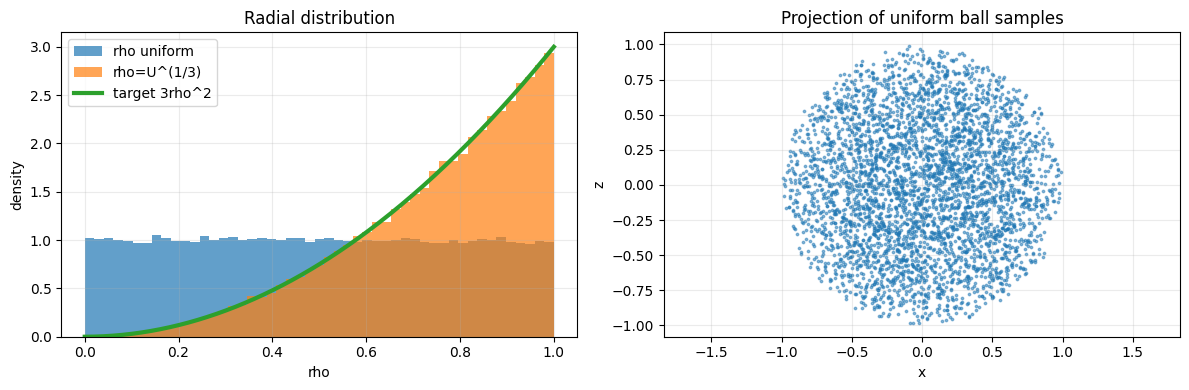

In [26]:
rng = np.random.default_rng(17)
n = 80_000
R = 1.0

# Incorrect radial sampling
rho_bad = rng.uniform(0, R, n)
phi_bad = np.arccos(1 - 2*rng.uniform(0, 1, n))
theta_bad = 2*np.pi*rng.uniform(0, 1, n)
X_bad, Y_bad, Z_bad = spherical_to_cart(rho_bad, phi_bad, theta_bad)

# Correct radial sampling
rho_good = R*rng.uniform(0, 1, n)**(1/3)
phi_good = np.arccos(1 - 2*rng.uniform(0, 1, n))
theta_good = 2*np.pi*rng.uniform(0, 1, n)
X_good, Y_good, Z_good = spherical_to_cart(rho_good, phi_good, theta_good)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
bins = np.linspace(0, 1, 50)
axes[0].hist(rho_bad, bins=bins, density=True, alpha=0.7, label="rho uniform")
axes[0].hist(rho_good, bins=bins, density=True, alpha=0.7, label="rho=U^(1/3)")
rho_line = np.linspace(0, 1, 300)
axes[0].plot(rho_line, 3*rho_line**2, linewidth=3, label="target 3rho^2")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("density")
axes[0].set_title("Radial distribution")
axes[0].legend()
axes[0].grid(True, alpha=0.25)

axes[1].scatter(X_good[:4000], Z_good[:4000], s=3, alpha=0.5)
axes[1].set_xlabel("x")
axes[1].set_ylabel("z")
axes[1].set_title("Projection of uniform ball samples")
axes[1].axis("equal")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 23. Probability of being near the center

For a uniform point in the unit ball,

$$
P(\rho\le 0.5)=0.5^3=\frac18.
$$

In [27]:
prob_est = np.mean(rho_good <= 0.5)
print("Estimated probability rho <= 0.5:", prob_est)
print("Exact probability:", 0.5**3)

Estimated probability rho <= 0.5: 0.1257125
Exact probability: 0.125


---

# Part XI. Monte Carlo checks

Monte Carlo integration gives independent checks on coordinate-based calculations.

## 24. Monte Carlo check for a spherical shell

In [28]:
def shell_mask(X, Y, Z):
    rho = np.sqrt(X**2 + Y**2 + Z**2)
    return (rho >= 1) & (rho <= 2.5)

exact_shell = 4*np.pi*(2.5**3 - 1**3)/3

for n in [10_000, 50_000, 200_000, 600_000]:
    est, se, *_ = monte_carlo_solid(
        one3,
        -2.5, 2.5,
        -2.5, 2.5,
        -2.5, 2.5,
        shell_mask,
        n=n,
        seed=1717+n
    )
    print(f"n={n:8d}, estimate={est:.6f}, SE={se:.6f}, error={est-exact_shell:.6f}")

print("Exact shell volume:", exact_shell)

n=   10000, estimate=60.687500, SE=0.624768, error=-0.573557
n=   50000, estimate=61.220000, SE=0.279453, error=-0.041057
n=  200000, estimate=61.069375, SE=0.139718, error=-0.191682
n=  600000, estimate=61.231042, SE=0.080671, error=-0.030015
Exact shell volume: 61.261056745000964


## 25. Monte Carlo check for a cylinder integral

In [29]:
def cylinder_radius1_height2_mask(X, Y, Z):
    return (X**2 + Y**2 <= 1) & (0 <= Z) & (Z <= 2)

for n in [10_000, 50_000, 200_000, 600_000]:
    est, se, *_ = monte_carlo_solid(
        density_cyl_radial,
        -1, 1,
        -1, 1,
        0, 2,
        cylinder_radius1_height2_mask,
        n=n,
        seed=1720+n
    )
    print(f"n={n:8d}, estimate={est:.6f}, SE={se:.6f}, error={est-exact_mass_cyl:.6f}")

print("Exact mass:", exact_mass_cyl)

n=   10000, estimate=9.453422, SE=0.052979, error=0.028644
n=   50000, estimate=9.414416, SE=0.023893, error=-0.010362
n=  200000, estimate=9.421966, SE=0.011929, error=-0.002812
n=  600000, estimate=9.439851, SE=0.006877, error=0.015073
Exact mass: 9.42477796076938


---

# Part XII. Coordinate choice examples

Coordinate choice is an act of simplification.

Use cylindrical coordinates when the problem features:

$$
x^2+y^2,\qquad \text{vertical axis symmetry},\qquad \text{cylinders or cones}.
$$

Use spherical coordinates when the problem features:

$$
x^2+y^2+z^2,\qquad \text{origin-centered radial symmetry},\qquad \text{spheres or shells}.
$$

## 26. Example comparison table

In [30]:
examples = [
    ("solid cylinder x^2+y^2<=4, 0<=z<=3", "cylindrical"),
    ("ball x^2+y^2+z^2<=9", "spherical"),
    ("cone z=sqrt(x^2+y^2)", "cylindrical"),
    ("spherical shell 1<=x^2+y^2+z^2<=4", "spherical"),
    ("box 0<=x,y,z<=1", "Cartesian"),
    ("paraboloid z=1-x^2-y^2 over disk", "cylindrical"),
]

print(f"{'region/integrand feature':55s} {'best coordinates'}")
print("-"*76)
for desc, choice in examples:
    print(f"{desc:55s} {choice}")

region/integrand feature                                best coordinates
----------------------------------------------------------------------------
solid cylinder x^2+y^2<=4, 0<=z<=3                      cylindrical
ball x^2+y^2+z^2<=9                                     spherical
cone z=sqrt(x^2+y^2)                                    cylindrical
spherical shell 1<=x^2+y^2+z^2<=4                       spherical
box 0<=x,y,z<=1                                         Cartesian
paraboloid z=1-x^2-y^2 over disk                        cylindrical


---

# Part XIII. Chapter mini-project: layered spherical planet

A simple model of a planet is a ball of radius $R=1$ with density depending only on radius:

$$
\delta(\rho)=
\begin{cases}
5, & 0\le\rho\le0.35,\\
3, & 0.35<\rho\le0.75,\\
1, & 0.75<\rho\le1.
\end{cases}
$$

You will compute:

1. total mass;
2. fraction of mass in each layer;
3. average density;
4. average value of $\rho^2$;
5. a Monte Carlo check.

## 27. Define the layered density

In [31]:
def layered_density_by_rho(rho):
    rho = np.asarray(rho)
    return np.where(rho <= 0.35, 5.0,
           np.where(rho <= 0.75, 3.0, 1.0))

def layered_density_cart(X, Y, Z):
    rho = np.sqrt(X**2 + Y**2 + Z**2)
    return layered_density_by_rho(rho)

R = 1.0

mass_layered = spherical_midpoint_integral(
    layered_density_cart,
    0,
    lambda phi, theta: 1.0,
    0, np.pi,
    0, 2*np.pi,
    nrho=300,
    nphi=120,
    ntheta=140
)

volume_unit_ball = 4*np.pi/3
avg_density_layered = mass_layered/volume_unit_ball

print("Layered planet mass estimate:", mass_layered)
print("Unit ball volume:", volume_unit_ball)
print("Average density:", avg_density_layered)

Layered planet mass estimate: 8.082464282537641
Unit ball volume: 4.1887902047863905
Average density: 1.9295462143943327


## 28. Exact layer masses

For a shell $a\le\rho\le b$ with constant density $c$,

$$
m=c\cdot\frac{4\pi}{3}(b^3-a^3).
$$

In [32]:
layers = [
    (0.0, 0.35, 5.0, "core"),
    (0.35, 0.75, 3.0, "mantle"),
    (0.75, 1.00, 1.0, "crust")
]

exact_masses = []
for a, b, density, name in layers:
    m = density*4*np.pi*(b**3-a**3)/3
    exact_masses.append(m)
    print(f"{name:8s} mass = {m:.8f}")

exact_total = sum(exact_masses)
print("Exact total mass:", exact_total)
print("Numerical total mass:", mass_layered)
print("Layer mass fractions:", np.array(exact_masses)/exact_total)

core     mass = 0.89797190
mantle   mass = 4.76265446
crust    mass = 2.42164434
Exact total mass: 8.082270700135341
Numerical total mass: 8.082464282537641
Layer mass fractions: [0.111104 0.589272 0.299624]


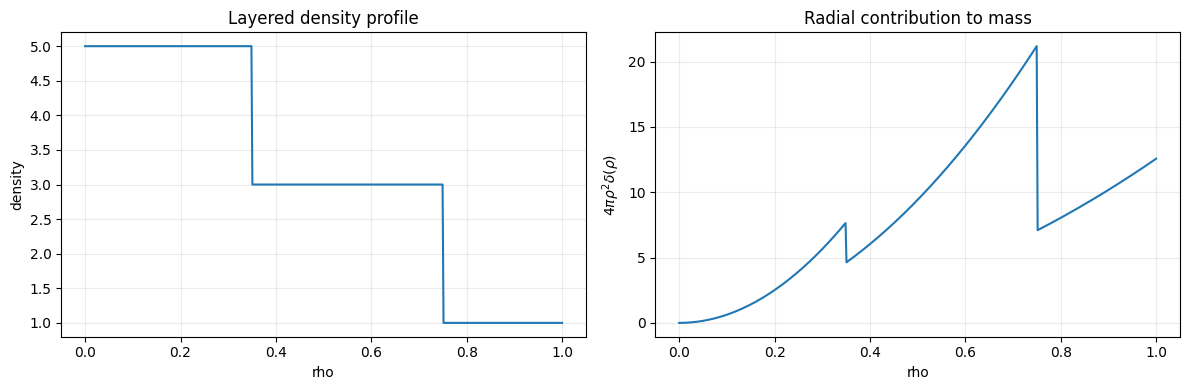

In [33]:
rho_line = np.linspace(0, 1, 500)
density_line = layered_density_by_rho(rho_line)
radial_mass_density = 4*np.pi*rho_line**2*density_line

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rho_line, density_line)
axes[0].set_xlabel("rho")
axes[0].set_ylabel("density")
axes[0].set_title("Layered density profile")
axes[0].grid(True, alpha=0.25)

axes[1].plot(rho_line, radial_mass_density)
axes[1].set_xlabel("rho")
axes[1].set_ylabel(r"$4\pi\rho^2\delta(\rho)$")
axes[1].set_title("Radial contribution to mass")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

## 29. Average $\rho^2$ for the layered planet

In [34]:
def rho2_layered_density(X, Y, Z):
    rho2 = X**2 + Y**2 + Z**2
    return rho2*layered_density_cart(X, Y, Z)

rho2_mass_integral = spherical_midpoint_integral(
    rho2_layered_density,
    0,
    lambda phi, theta: 1.0,
    0, np.pi,
    0, 2*np.pi,
    nrho=300,
    nphi=120,
    ntheta=140
)

avg_rho2_layered = rho2_mass_integral/mass_layered

# Exact: numerator = ∑ density*4π∫_a^b rho^4 d rho = ∑ density*4π(b^5-a^5)/5
exact_num = sum(density*4*np.pi*(b**5-a**5)/5 for a, b, density, name in layers)
exact_avg_rho2 = exact_num/exact_total

print("Average rho^2 estimate:", avg_rho2_layered)
print("Exact average rho^2:", exact_avg_rho2)

Average rho^2 estimate: 0.46180960640803415
Exact average rho^2: 0.46181303446488725


## 30. Monte Carlo check for the layered planet

In [35]:
def unit_ball_mask(X, Y, Z):
    return X**2 + Y**2 + Z**2 <= 1

for n in [20_000, 80_000, 250_000, 600_000]:
    est, se, *_ = monte_carlo_solid(
        layered_density_cart,
        -1, 1,
        -1, 1,
        -1, 1,
        unit_ball_mask,
        n=n,
        seed=1730+n
    )
    print(f"n={n:8d}, mass estimate={est:.6f}, SE={se:.6f}, error={est-exact_total:.6f}")

n=   20000, mass estimate=7.932400, SE=0.071636, error=-0.149871
n=   80000, mass estimate=8.058200, SE=0.035983, error=-0.024071
n=  250000, mass estimate=8.084064, SE=0.020419, error=0.001793
n=  600000, mass estimate=8.093680, SE=0.013185, error=0.011409


## 31. Mini-project questions

Answer the following in a markdown cell:

1. Why are spherical coordinates the natural choice for this density?
2. Why does the mass contribution contain the factor $4\pi\rho^2$?
3. Which layer has the largest mass? Is it the densest layer?
4. How does the average density compare with the density of each layer?
5. How would the calculation change if density also depended on $\phi$?

In [36]:
print("Mini-project summary")
print("--------------------")
print("Exact total mass:", exact_total)
print("Numerical total mass:", mass_layered)
print("Average density:", avg_density_layered)
print("Exact average rho^2:", exact_avg_rho2)
for (a, b, density, name), m in zip(layers, exact_masses):
    print(f"{name:8s}: radius interval [{a}, {b}], density={density}, mass fraction={m/exact_total:.4f}")

Mini-project summary
--------------------
Exact total mass: 8.082270700135341
Numerical total mass: 8.082464282537641
Average density: 1.9295462143943327
Exact average rho^2: 0.46181303446488725
core    : radius interval [0.0, 0.35], density=5.0, mass fraction=0.1111
mantle  : radius interval [0.35, 0.75], density=3.0, mass fraction=0.5893
crust   : radius interval [0.75, 1.0], density=1.0, mass fraction=0.2996


---

# Part XIV. Additional exercises with reference solutions

Try each exercise before running the reference solution.

## Exercise A. Cylindrical volume

Use cylindrical coordinates to compute the volume of

$$
0\le r\le3,\qquad 0\le z\le4,\qquad 0\le\theta\le2\pi.
$$

In [37]:
# Exercise A workspace

# Your code here

### Reference solution for Exercise A

In [38]:
val_A = cylindrical_midpoint_integral(
    one3,
    0, 3,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: 4,
    nr=120,
    nt=160,
    nz=30
)
print("Numerical volume:", val_A)
print("Exact volume:", np.pi*3**2*4)

Numerical volume: 3.7699111843077002
Exact volume: 113.09733552923255


## Exercise B. Cone volume

Compute the volume of

$$
0\le z\le 2-r,\qquad 0\le r\le2,\qquad 0\le\theta\le2\pi.
$$

In [39]:
# Exercise B workspace

# Your code here

### Reference solution for Exercise B

In [40]:
val_B = cylindrical_midpoint_integral(
    one3,
    0, 2,
    0, 2*np.pi,
    lambda r, th: 0,
    lambda r, th: 2-r,
    nr=160,
    nt=180,
    nz=50
)
print("Numerical volume:", val_B)
print("Exact cone volume:", (1/3)*np.pi*2**2*2)

Numerical volume: 0.16755488068381244
Exact cone volume: 8.377580409572781


## Exercise C. Spherical shell

Compute the volume of the spherical shell

$$
2\le\rho\le5.
$$

In [41]:
# Exercise C workspace

# Your code here

### Reference solution for Exercise C

In [42]:
val_C = spherical_midpoint_integral(
    one3,
    2,
    lambda phi, theta: 5,
    0, np.pi,
    0, 2*np.pi,
    nrho=160,
    nphi=120,
    ntheta=160
)
print("Numerical volume:", val_C)
print("Exact volume:", 4*np.pi*(5**3-2**3)/3)

Numerical volume: 490.1013456308436
Exact volume: 490.0884539600077


## Exercise D. Spherical integral

Compute

$$
\iiint_{\rho\le2} z^2\,dV.
$$

By symmetry, this is one third of

$$
\iiint_{\rho\le2}(x^2+y^2+z^2)\,dV.
$$

In [43]:
# Exercise D workspace

# Your code here

### Reference solution for Exercise D

In [44]:
def z_squared(X, Y, Z):
    return Z**2

val_D = spherical_midpoint_integral(
    z_squared,
    0,
    lambda phi, theta: 2,
    0, np.pi,
    0, 2*np.pi,
    nrho=180,
    nphi=150,
    ntheta=160
)
exact_D = (1/3)*(4*np.pi*2**5/5)

print("Numerical value:", val_D)
print("Exact value:", exact_D)

Numerical value: 26.80903782260361
Exact value: 26.8082573106329


## Exercise E. Uniform ball probability

For a point uniformly distributed in the ball of radius $4$, compute

$$
P(\rho\le1).
$$

In [45]:
# Exercise E workspace

# Your code here

### Reference solution for Exercise E

In [46]:
R = 4.0
a = 1.0
print("Exact probability:", (a/R)**3)

rng = np.random.default_rng(170)
n = 100_000
rho = R*rng.uniform(0, 1, n)**(1/3)
estimate = np.mean(rho <= a)
print("Simulation estimate:", estimate)

Exact probability: 0.015625
Simulation estimate: 0.01606


---

# Formula summary

## Cylindrical coordinates

$$
x=r\cos\theta,\qquad y=r\sin\theta,\qquad z=z.
$$

## Cylindrical volume element

$$
dV=r\,dz\,dr\,d\theta.
$$

## Spherical coordinates

$$
x=\rho\sin\phi\cos\theta,
\qquad
y=\rho\sin\phi\sin\theta,
\qquad
z=\rho\cos\phi.
$$

## Spherical volume element

$$
dV=\rho^2\sin\phi\,d\rho\,d\phi\,d\theta.
$$

## Ball

$$
0\le\rho\le R,\qquad 0\le\phi\le\pi,\qquad 0\le\theta\le2\pi.
$$

## Upper cone around the positive $z$-axis

$$
0\le\phi\le\phi_0.
$$

## Spherical shell

$$
a\le\rho\le b.
$$

## Radial density in a ball

If $\delta=\delta(\rho)$, then

$$
m=4\pi\int_0^R \delta(\rho)\rho^2\,d\rho.
$$

## Uniform ball sampling

For a uniform point in a ball of radius $R$,

$$
\rho=R\,U^{1/3},\qquad
\phi=\arccos(1-2V),\qquad
\theta=2\pi W.
$$

# End of Chapter 17 Lab

You have used Python to explore:

- cylindrical coordinates,
- spherical coordinates,
- coordinate grids and geometry,
- Jacobian determinants,
- cylinder, cone, ball, shell, and cap integrals,
- radial Gaussian integrals,
- mass and average value with radial densities,
- probability in balls,
- Monte Carlo checks,
- coordinate-choice strategy,
- and a layered spherical planet mini-project.

These ideas prepare for vector fields in three dimensions, surface integrals, flux, the divergence theorem, and applications in physics, probability, and geometry.